In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [3]:
data = []
labels = []
file_name = []

target_size = (256, 256)
dataset_path = "/content/drive/MyDrive/PROJECT_PCD/Dataset"

# Sort folder kelas
for sub_folder in sorted(os.listdir(dataset_path)):

    sub_folder_path = os.path.join(dataset_path, sub_folder)

    # Pastikan yang dibaca hanya folder
    if os.path.isdir(sub_folder_path):

        # Sort file gambar
        for filename in sorted(os.listdir(sub_folder_path)):

            img_path = os.path.join(sub_folder_path, filename)

            img = cv.imread(img_path)

            # Lewati jika gambar gagal dibaca
            if img is None:
                print(f"Gagal membaca: {img_path}")
                continue

            img = img.astype(np.uint8)
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, target_size)

            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

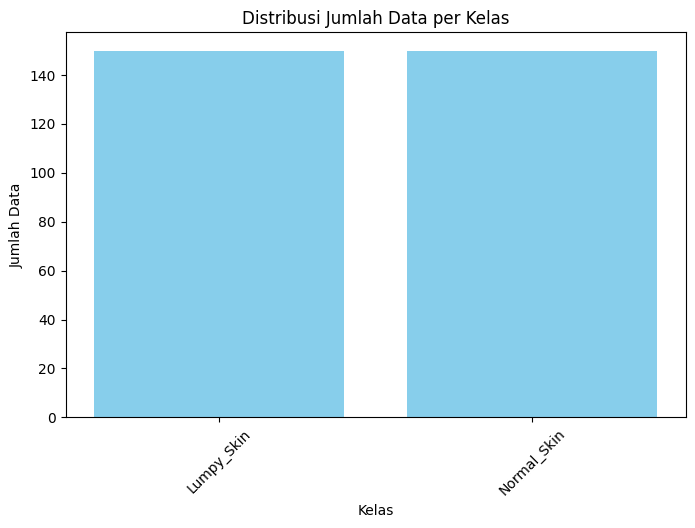

In [4]:
# Menampilkan jumlah data per kelas
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique_labels, counts, color='skyblue')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Jumlah Data per Kelas")
plt.xticks(rotation=45)
plt.show()

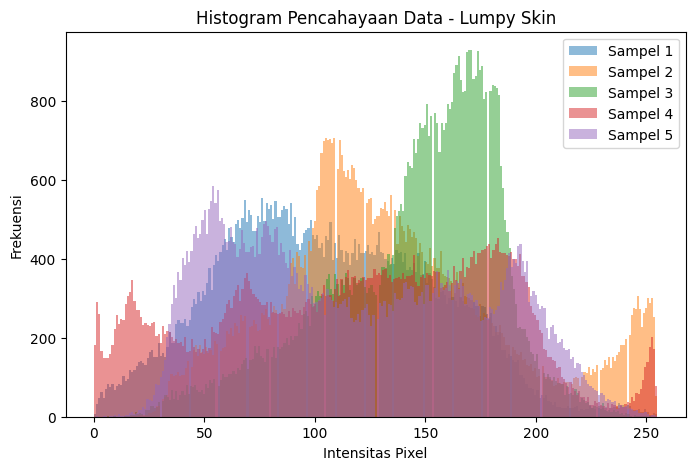

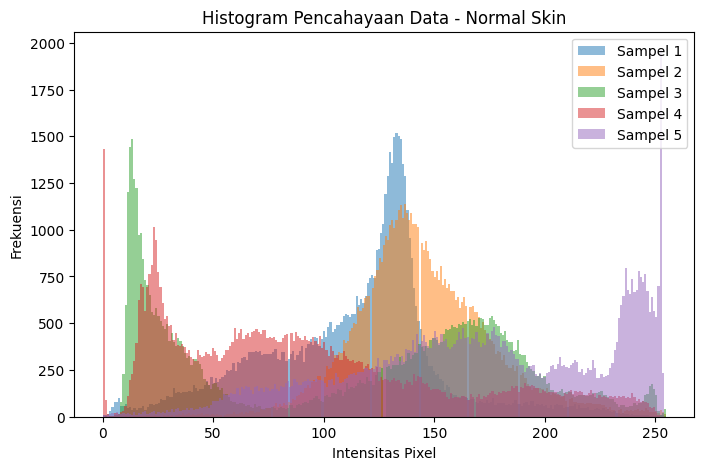

In [5]:
Lumpy_Skin = [data[i] for i in range(len(labels)) if labels[i] == "Lumpy_Skin"]
Normal_skin = [data[i] for i in range(len(labels)) if labels[i] == "Normal_Skin"]

plt.figure(figsize=(8, 5))
for i in range(min(5, len(Lumpy_Skin))):
    img = Lumpy_Skin[i]
    plt.hist(img.ravel(), bins=256, alpha=0.5, label=f'Sampel {i+1}')
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.title("Histogram Pencahayaan Data - Lumpy Skin")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for i in range(min(5, len(Normal_skin))):
    img = Normal_skin[i]
    plt.hist(img.ravel(), bins=256, alpha=0.5, label=f'Sampel {i+1}')
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.title("Histogram Pencahayaan Data - Normal Skin")
plt.legend()
plt.show()

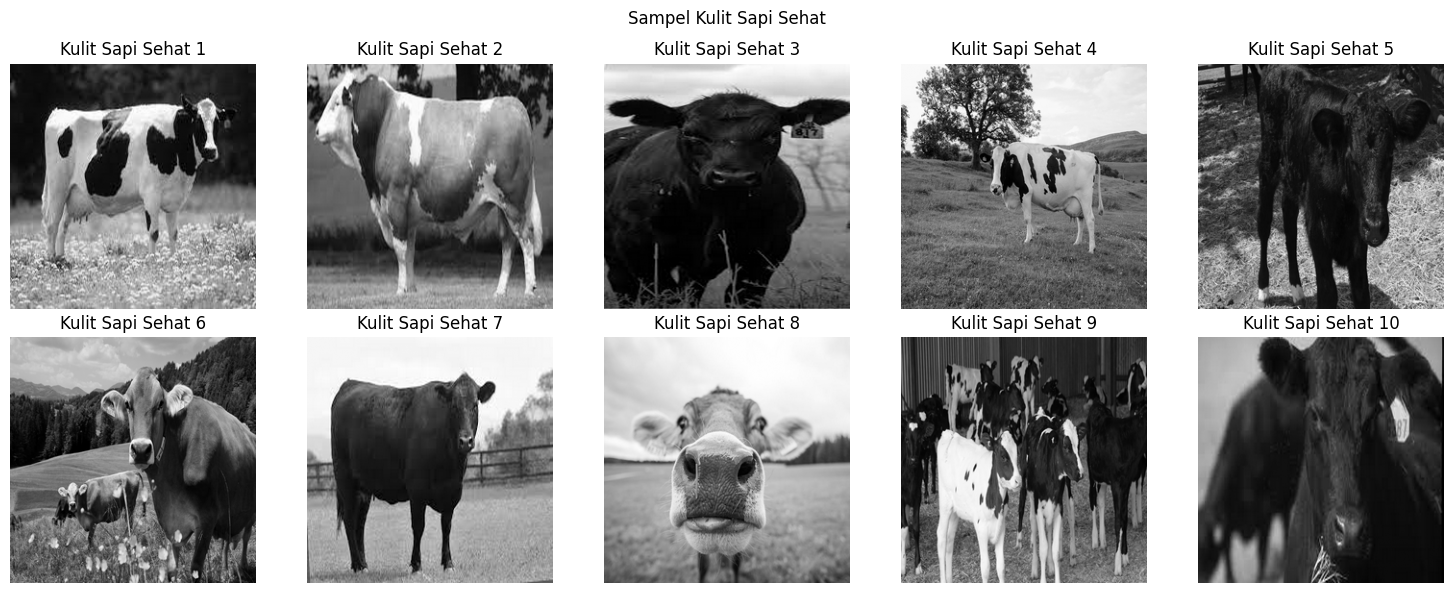

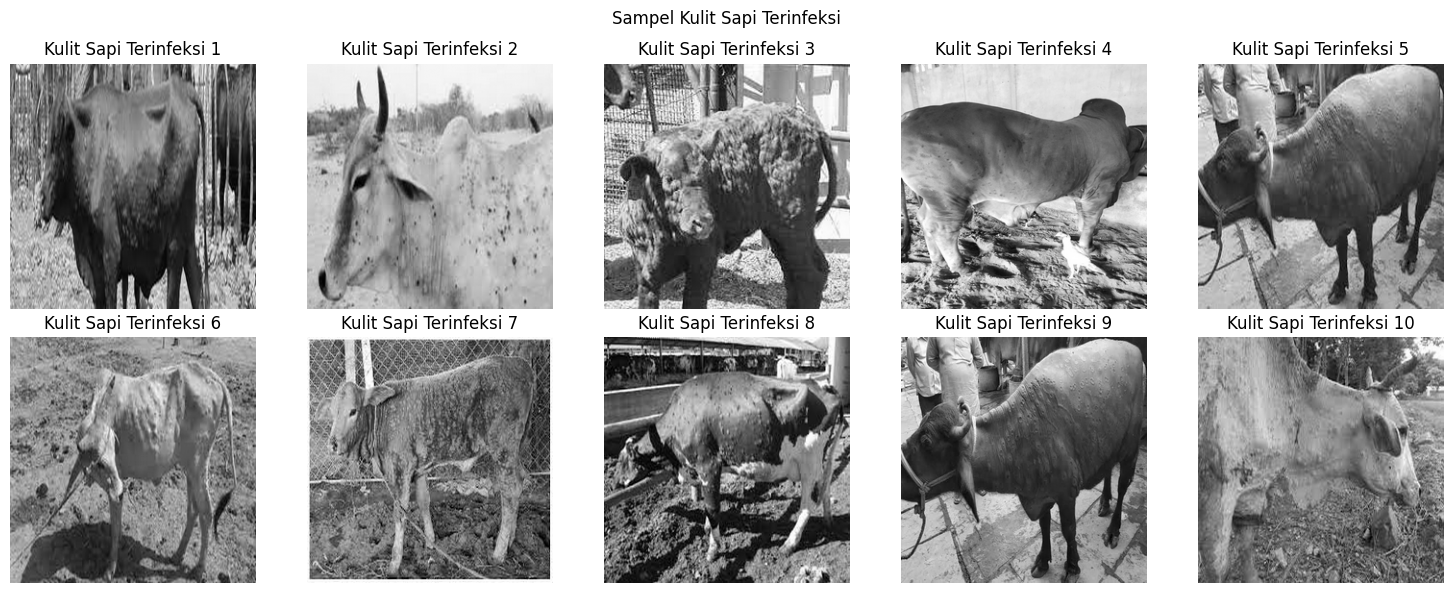

In [6]:
import random

# Menampilkan sampel kulit sapi sehat
random_normal = random.sample(Normal_skin, min(10, len(Normal_skin)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(random_normal))):
    axes[i].imshow(random_normal[i], cmap="gray")
    axes[i].set_title(f"Kulit Sapi Sehat {i+1}")
    axes[i].axis("off")
plt.suptitle("Sampel Kulit Sapi Sehat")
plt.tight_layout()
plt.show()

# Menampilkan sampel kulit sapi terinfeksi
random_lumpy = random.sample(Lumpy_Skin, min(10, len(Lumpy_Skin)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(random_lumpy))):
    axes[i].imshow(random_lumpy[i], cmap="gray")
    axes[i].set_title(f"Kulit Sapi Terinfeksi {i+1}")
    axes[i].axis("off")
plt.suptitle("Sampel Kulit Sapi Terinfeksi")
plt.tight_layout()
plt.show()

In [7]:
augmented_data = []
augmented_labels = []
augmented_filenames = []

for i in range(len(data)):
    img = data[i]
    label = labels[i]
    filename = file_name[i]

    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)
    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)
    # 3. Rotasi 90 Derajat
    img_rot_90 = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)
    # 4. Rotasi 180 Derajat
    img_rot_180 = cv.rotate(img, cv.ROTATE_180)

    for img_aug, suffix in [(img_flip_h, 'flip_h'), (img_flip_v, 'flip_v'),
                             (img_rot_90, 'rot_90'), (img_rot_180, 'rot_180')]:
        augmented_data.append(img_aug)
        augmented_labels.append(label)
        augmented_filenames.append(f"{filename}_{suffix}")

print(f"Jumlah data sebelum augmentasi: {len(data)}")
print(f"Jumlah data setelah augmentasi: {len(augmented_data)}")

# Ganti variabel yang digunakan selanjutnya
dataPreprocessed = augmented_data
labels_preprocessed = augmented_labels
file_name = augmented_filenames

Jumlah data sebelum augmentasi: 300
Jumlah data setelah augmentasi: 1200


In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [9]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [10]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [11]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [12]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [13]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [14]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [15]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [16]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [17]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [18]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [19]:
for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [20]:
for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [21]:
for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [22]:
for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [23]:
for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [24]:
for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [25]:
dataTable = {'Filename': file_name, 'Label': labels_preprocessed,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_grayscale.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_grayscale.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Lumpy_Skin_102.png_flip_h,Lumpy_Skin,435.056710,805.595694,387.635723,658.500346,0.111632,0.063813,0.112288,0.069801,...,0.000129,0.000087,0.010977,0.008950,0.011379,0.009340,0.906027,0.825573,0.916080,0.857416
1,Lumpy_Skin_102.png_flip_v,Lumpy_Skin,435.056710,805.595694,387.635723,658.500346,0.111632,0.063813,0.112288,0.069801,...,0.000129,0.000087,0.010977,0.008950,0.011379,0.009340,0.906027,0.825573,0.916080,0.857416
2,Lumpy_Skin_102.png_rot_90,Lumpy_Skin,387.635723,805.595694,435.056710,658.500346,0.112288,0.063813,0.111632,0.069801,...,0.000121,0.000087,0.011379,0.008950,0.010977,0.009340,0.916080,0.825573,0.906027,0.857416
3,Lumpy_Skin_102.png_rot_180,Lumpy_Skin,435.056710,658.500346,387.635723,805.595694,0.111632,0.069801,0.112288,0.063813,...,0.000129,0.000080,0.010977,0.009340,0.011379,0.008950,0.906027,0.857416,0.916080,0.825573
4,Lumpy_Skin_103.png_flip_h,Lumpy_Skin,374.677145,443.783345,105.478860,429.366198,0.169619,0.149118,0.251702,0.146973,...,0.000396,0.000200,0.015294,0.014362,0.019906,0.014133,0.931069,0.918132,0.980632,0.920792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Normal_Skin_97.png_rot_180,Normal_Skin,161.443444,206.488981,79.143459,214.849012,0.141960,0.128077,0.210958,0.126687,...,0.000497,0.000290,0.018109,0.017128,0.022291,0.017044,0.925244,0.904260,0.963283,0.900382
1196,Normal_Skin_98.png_flip_h,Normal_Skin,526.410340,625.402937,351.885018,674.766905,0.151548,0.143213,0.175066,0.141808,...,0.000484,0.000423,0.021445,0.020395,0.022005,0.020557,0.909174,0.891764,0.939061,0.883223
1197,Normal_Skin_98.png_flip_v,Normal_Skin,526.410340,625.402937,351.885018,674.766905,0.151548,0.143213,0.175066,0.141808,...,0.000484,0.000423,0.021445,0.020395,0.022005,0.020557,0.909174,0.891764,0.939061,0.883223
1198,Normal_Skin_98.png_rot_90,Normal_Skin,351.885018,625.402937,526.410340,674.766905,0.175066,0.143213,0.151548,0.141808,...,0.000460,0.000423,0.022005,0.020395,0.021445,0.020557,0.939061,0.891764,0.909174,0.883223


<Axes: >

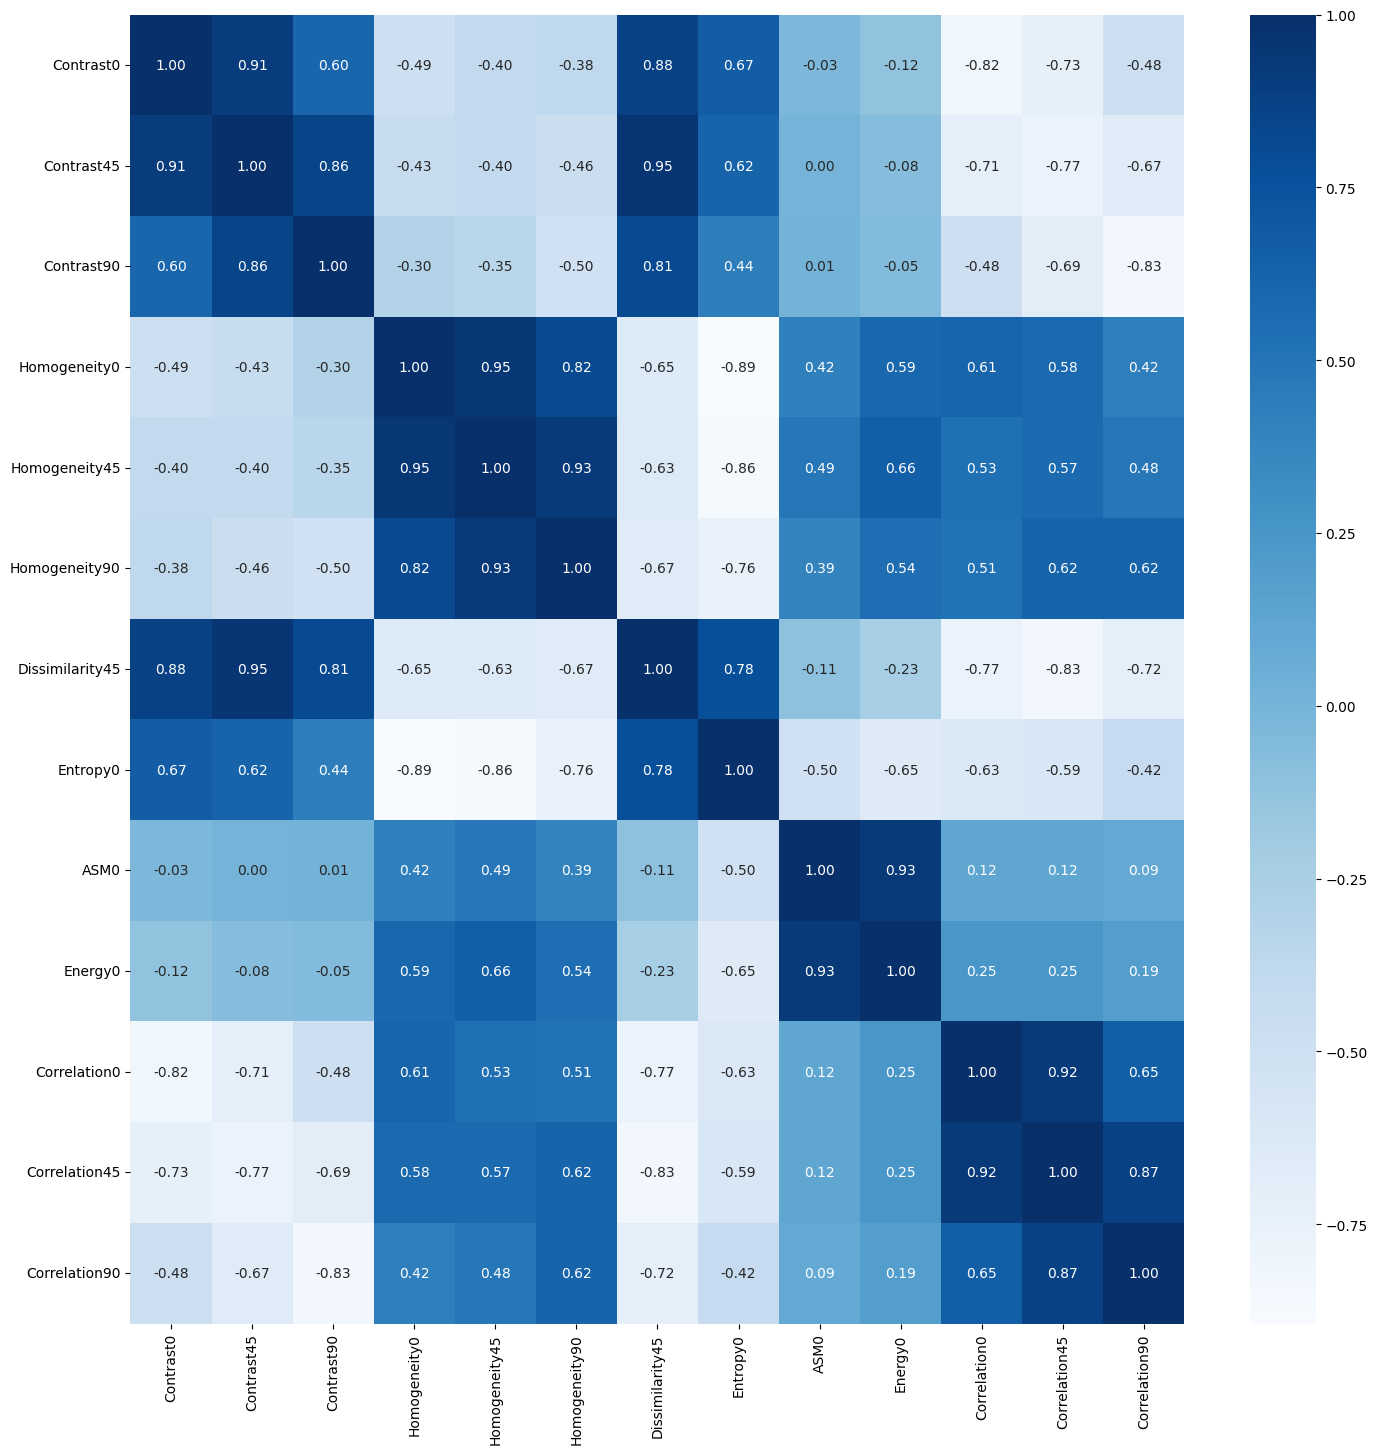

In [26]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [27]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(960, 13)
(240, 13)


In [28]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [29]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

In [30]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       1.00      1.00      1.00       478
 Normal_Skin       1.00      1.00      1.00       482

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960

[[478   0]
 [  0 482]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.95      0.94      0.95       122
 Normal_Skin       0.94      0.95      0.95       118

    accuracy                           0.95       240
   macro avg       0.95      0.95      0.95       240
weighted avg       0.95      0.95      0.95       240

[[115   7]
 [  6 112]]
Accuracy: 0.9458333333333333


In [31]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.71      0.82      0.76       478
 Normal_Skin       0.79      0.66      0.72       482

    accuracy                           0.74       960
   macro avg       0.75      0.74      0.74       960
weighted avg       0.75      0.74      0.74       960

[[393  85]
 [164 318]]
Accuracy: 0.740625

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.70      0.77      0.73       122
 Normal_Skin       0.73      0.65      0.69       118

    accuracy                           0.71       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.71      0.71      0.71       240

[[94 28]
 [41 77]]
Accuracy: 0.7125


In [32]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.95      0.96      0.95       478
 Normal_Skin       0.96      0.95      0.95       482

    accuracy                           0.95       960
   macro avg       0.95      0.95      0.95       960
weighted avg       0.95      0.95      0.95       960

[[460  18]
 [ 26 456]]
Accuracy: 0.9541666666666667

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.87      0.90      0.88       122
 Normal_Skin       0.89      0.86      0.87       118

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240

[[110  12]
 [ 17 101]]
Accuracy: 0.8791666666666667


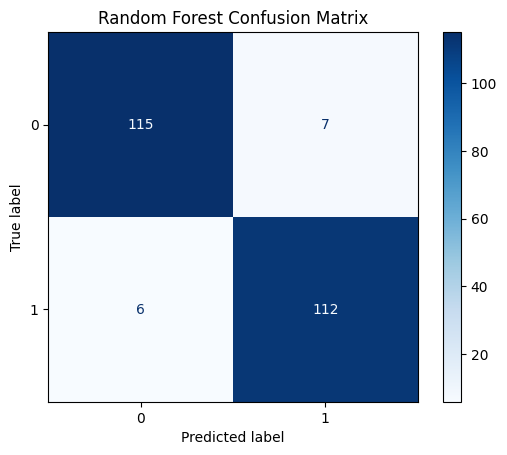

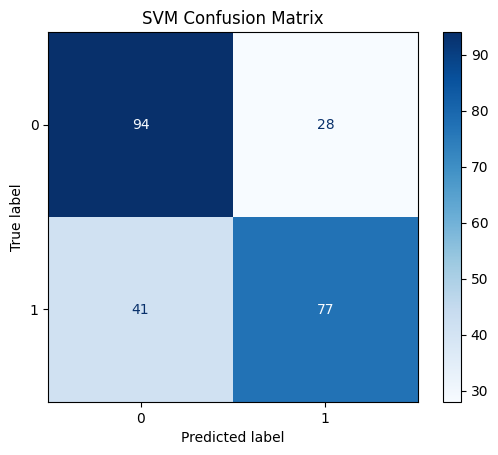

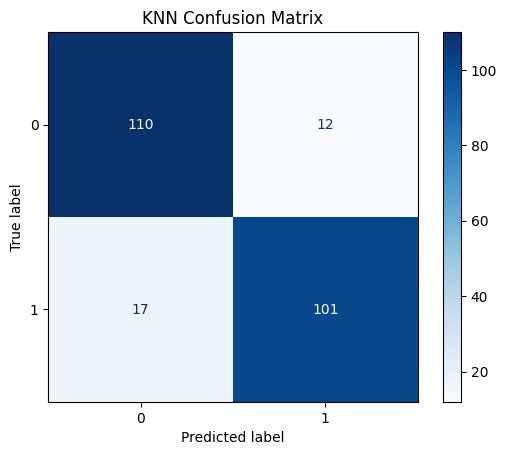

In [33]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

# Analisis Hasil Klasifikasi Citra Kulit Sapi
### 1 Karakteristik Random Forest yang Cocok untuk Data Ini

Random Forest adalah algoritma *ensemble* berbasis banyak pohon keputusan yang digabungkan (voting). Keunggulannya dalam konteks dataset ini antara lain:

- **Tahan terhadap noise dan variasi kecil** Fitur GLCM yang diekstrak pada 4 sudut (0°, 45°, 90°, 135°) menghasilkan banyak dimensi. RF mampu memilih sendiri subset fitur terbaik di setiap pohon (*feature subsampling*), sehingga tidak terpengaruh oleh fitur yang kurang relevan.
- **Ensemble voting mereduksi varians** Meskipun training accuracy RF mencapai 100% (indikasi overfitting di level pohon individual), mekanisme voting antar 100 pohon membuat model tetap generalize dengan baik ke data testing (94.58%). Ini menunjukkan bahwa RF secara natural mengkompensasi overfitting.
- **Tidak sensitif terhadap skala fitur** Meskipun normalisasi Z-score sudah dilakukan, RF berbasis pohon keputusan tidak bergantung pada jarak antar titik data, berbeda dengan SVM dan KNN yang sangat bergantung pada jarak.

### 2 Mengapa SVM Performanya Paling Rendah?

SVM dengan kernel RBF bekerja optimal ketika distribusi kelas dapat dipisahkan secara non-linear di ruang fitur yang ditransformasi. Namun pada kasus ini:

- **Distribusi fitur GLCM grayscale bisa overlapping** Beberapa fitur GLCM (terutama pada sudut yang berbeda) memiliki distribusi yang tumpang tindih antarkelas, sehingga *hyperplane* yang dibentuk SVM kurang optimal.
- **Sensitivitas terhadap parameter** SVM RBF sangat bergantung pada tuning parameter `C` dan `gamma`. Tanpa tuning (nilai default), performa SVM cenderung suboptimal.
- **Training accuracy rendah (74.06%)** Ini mengindikasikan bahwa SVM bahkan kesulitan mempelajari pola dari data training, bukan hanya masalah generalisasi.

### 3 Mengapa KNN Berada di Tengah?

KNN dengan k=3 menggunakan kedekatan jarak Euclidean antar sampel:

- **Sensitif terhadap augmentasi** Data augmentasi (flip dan rotasi) menghasilkan citra yang hampir identik satu sama lain. KNN yang berbasis kedekatan antar sampel sangat dipengaruhi oleh ini, sehingga pada data training performa sangat baik (95.42%), namun pada testing mulai turun karena ada variasi baru yang tidak ada tetangganya yang persis sama.
- **Gap training-testing paling besar** Gap 7.5% pada KNN lebih besar dibanding RF (5.42%) dan SVM (2.81%), menunjukkan bahwa KNN paling rentan terhadap overfitting di konteks dataset ini.

---

## Analisis: Mengapa Hanya Grayscale Menghasilkan Performa Terbaik?

### 1 Kualitas Dataset yang Sudah Baik

Dataset yang digunakan sudah memiliki **tekstur citra yang berkualitas tinggi** perbedaan visual antara kulit sapi sehat  dan kulit sapi terinfeksi sudah terlihat jelas secara tekstural bahkan dalam representasi grayscale. Lumpy Skin Disease menghasilkan nodul-nodul khas pada permukaan kulit yang memberikan pola tekstur berbeda secara signifikan dibanding kulit normal.

Karena perbedaan tekstur ini sudah sangat kuat pada level citra grayscale, GLCM sudah mampu menangkap fitur diskriminatif yang cukup tanpa perlu preprocessing tambahan.

### 2 Preprocessing Tambahan malah nambah menurunkan hasil

Ketika preprocessing tambahan diterapkan (misalnya histogram equalization, CLAHE, filtering, atau teknik enhancement lainnya), yang terjadi adalah:

- **Distorsi pola tekstur asli** Operasi seperti histogram equalization atau sharpening mengubah distribusi intensitas piksel. Perubahan ini dapat menghapus atau memperumit pola co-occurrence yang menjadi dasar perhitungan GLCM.
- **Fitur GLCM menjadi tidak stabil** Nilai fitur seperti Contrast, Homogeneity, dan Energy sangat sensitif terhadap perubahan intensitas piksel. Preprocessing yang agresif akan menggeser nilai-nilai ini secara tidak terkontrol, sehingga fitur kehilangan daya diskriminatifnya.
- **Informasi tekstur yang sudah cukup menjadi "kebisingan"** Alih-alih menambah informasi, preprocessing tambahan justru menambahkan variasi artifisial yang tidak ada hubungannya dengan kondisi biologis kulit sapi.

## kenapa melakukann percobaan ini 
   dikarenakan untuk mengetahui apakah ada perubahan dari hasil yang kami lakukan di dalam tahapan preprocecing lain 

## Kesimpulan

| Aspek | Temuan |
|-------|--------|
| Model terbaik | Random Forest (94.58% testing accuracy) |
| Model terlemah | SVM RBF (71.25% testing accuracy) |
| Alasan RF unggul | Ensemble voting, tahan noise, tidak sensitif skala |
| Alasan grayscale saja optimal | Dataset memiliki tekstur yang sudah kuat dan diskriminatif |
| Dampak preprocessing tambahan | Mendistorsi pola tekstur asli, menurunkan daya diskriminatif fitur GLCM |
